In [18]:

!git clone https://github.com/Xiuyu-Li/q-diffusion.git
%cd q-diffusion

!pip install "pip<24.1" -q


!pip install torch==1.13.1+cu116 torchvision==0.14.1+cu116 torchaudio==0.13.1 --extra-index-url https://download.pytorch.org/whl/cu116


!pip install omegaconf einops tqdm pytorch-lightning==1.6.5 transformers kornia scipy -q

!pip install -e . -q

Cloning into 'q-diffusion'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 175 (delta 23), reused 16 (delta 16), pack-reused 131 (from 1)
Receiving objects: 100% (175/175), 6.08 MiB | 30.24 MiB/s, done.
Resolving deltas: 100% (63/63), done.
/content/q-diffusion
DEPRECATION: pytorch-lightning 1.6.5 has a non-standard dependency specifier torch>=1.8.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu116
ERROR: Could not find a version that satisfies the requirement torch==1.13.1+cu116 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0

In [19]:

%cd /content/q-diffusion

!pip install "pip<24.1" -q

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

!pip install omegaconf einops tqdm transformers kornia scipy -q
!pip install pytorch-lightning==1.6.5 --no-deps -q

!pip install "protobuf>=3.20.2,<5.0.0" -q

!pip install -e . -q

/content/q-diffusion
DEPRECATION: pytorch-lightning 1.6.5 has a non-standard dependency specifier torch>=1.8.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
Looking in indexes: https://download.pytorch.org/whl/cu121
DEPRECATION: pytorch-lightning 1.6.5 has a non-standard dependency specifier torch>=1.8.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: pytorch-lightning 1.6.5 has a non-standard dependency specifier torch>=1.8.*. pip 24.1 will enforce this behaviour change. A possible replace

In [22]:
!pip install lmdb -q

DEPRECATION: pytorch-lightning 1.6.5 has a non-standard dependency specifier torch>=1.8.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [23]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
PyTorch: 2.10.0+cu128


In [29]:
# !pip install gdown -q

# import os
# os.makedirs("ckpts", exist_ok=True)

# !gdown --folder "https://drive.google.com/drive/folders/1ImRbmAvzCsU6AOaXbIeI7-4Gu2_Scc-X" -O ckpts/ --remaining-ok

In [6]:
# !ls -lh ckpts/

total 4.0K
drwxr-xr-x 2 root root 4.0K Apr 15 11:54 q-diffusion-ckpts


In [7]:
# ls -lh /content/q-diffusion/ckpts/q-diffusion-ckpts/cifar*

ls: cannot access '/content/q-diffusion/ckpts/q-diffusion-ckpts/cifar*': No such file or directory


In [31]:
# W4A8 ckpt.pth
!pip install gdown -q
!gdown 1NEyKcTlu5rSz6B-_cGOMbrR-FtZhZNuI -O cifar_w4a8_ckpt.pth

DEPRECATION: pytorch-lightning 1.6.5 has a non-standard dependency specifier torch>=1.8.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
Downloading...
From (original): https://drive.google.com/uc?id=1NEyKcTlu5rSz6B-_cGOMbrR-FtZhZNuI
From (redirected): https://drive.google.com/uc?id=1NEyKcTlu5rSz6B-_cGOMbrR-FtZhZNuI&confirm=t&uuid=21643d90-e795-4554-ac86-0a05d9f66f84
To: /content/q-diffusion/cifar_w4a8_ckpt.pth
100% 286M/286M [00:01<00:00, 149MB/s]


In [32]:
# W8A8 ckpt.pth
!gdown 1fS5Ez9Vvs2rDHFmBV2L4oIsMZxTBCeL4 -O cifar_w8a8_ckpt.pth

Downloading...
From (original): https://drive.google.com/uc?id=1fS5Ez9Vvs2rDHFmBV2L4oIsMZxTBCeL4
From (redirected): https://drive.google.com/uc?id=1fS5Ez9Vvs2rDHFmBV2L4oIsMZxTBCeL4&confirm=t&uuid=a06c4a4d-f1fd-46f0-aacd-49d9b73f40d6
To: /content/q-diffusion/cifar_w8a8_ckpt.pth
100% 286M/286M [00:02<00:00, 121MB/s]


In [33]:
# FP32 Baseline

!python scripts/sample_diffusion_ddim.py \
  --config configs/cifar10.yml \
  --use_pretrained \
  --timesteps 100 \
  --eta 0 \
  --skip_type quad \
  -l output_samples_fp32

2026-04-15 12:26:40.314685: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 12:26:40.336805: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776256000.361533   12958 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776256000.369522   12958 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776256000.391580   12958 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [34]:
#W8A8 Quantization
!python scripts/sample_diffusion_ddim.py \
  --config configs/cifar10.yml \
  --use_pretrained \
  --timesteps 100 \
  --eta 0 \
  --skip_type quad \
  --ptq \
  --weight_bit 8 \
  --quant_mode qdiff \
  --quant_act \
  --act_bit 8 \
  --a_sym \
  --split \
  --resume \
  -l output_samples_w8a8 \
  --cali_ckpt cifar_w8a8_ckpt.pth

2026-04-15 13:01:24.479616: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 13:01:24.498849: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776258084.521191   22053 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776258084.528529   22053 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776258084.547394   22053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [35]:
# W4A8 Quantization
!python scripts/sample_diffusion_ddim.py \
  --config configs/cifar10.yml \
  --use_pretrained \
  --timesteps 100 \
  --eta 0 \
  --skip_type quad \
  --ptq \
  --weight_bit 4 \
  --quant_mode qdiff \
  --quant_act \
  --act_bit 8 \
  --a_sym \
  --split \
  --resume \
  -l output_samples_w4a8 \
  --cali_ckpt cifar_w4a8_ckpt.pth

2026-04-15 14:38:35.198059: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 14:38:35.217523: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776263915.240086   47294 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776263915.247436   47294 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776263915.266591   47294 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

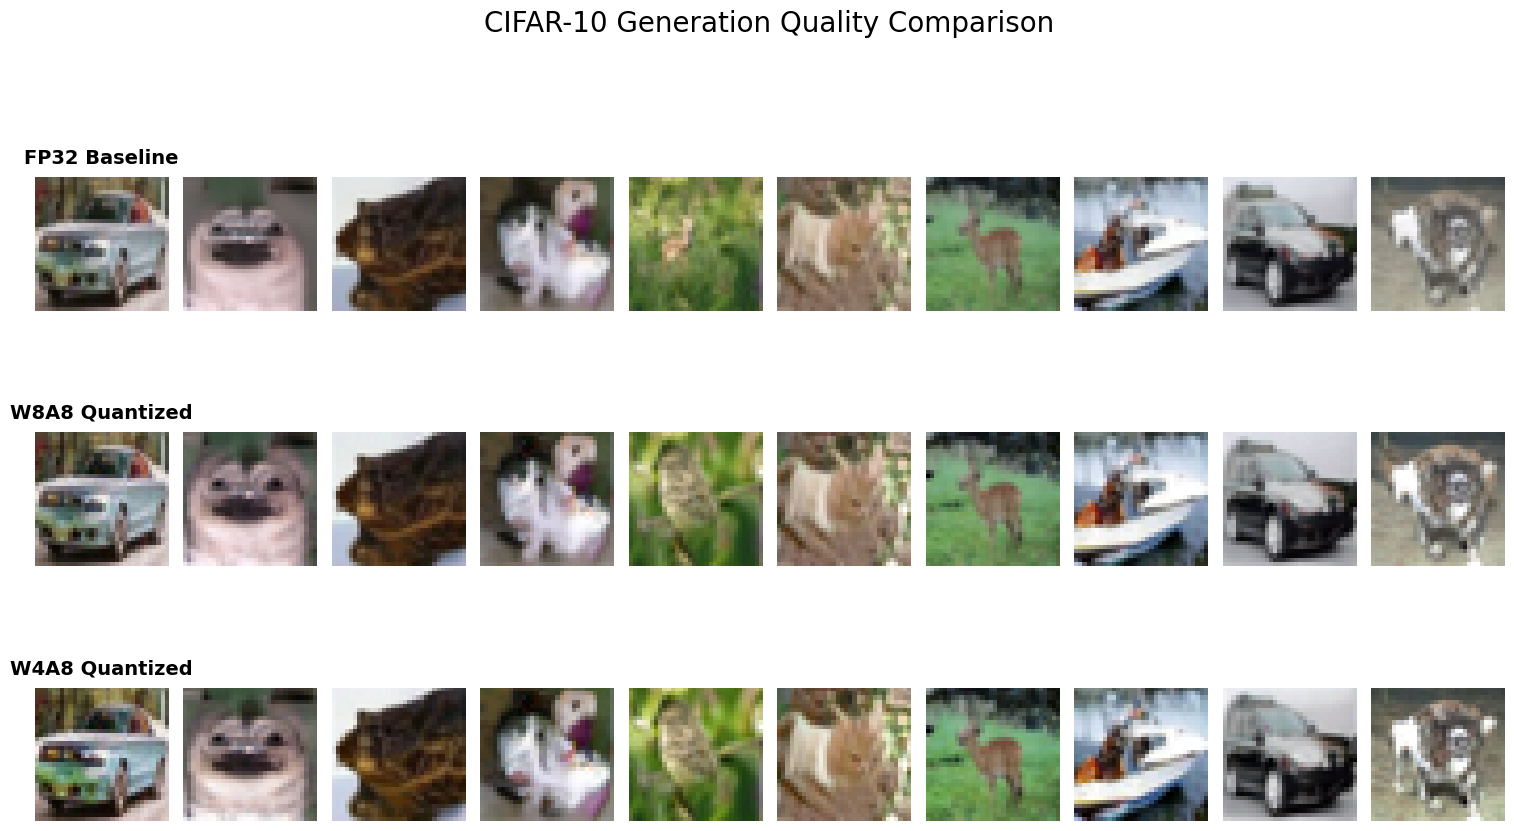

In [36]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os

directories = {
    "FP32 Baseline": "output_samples_fp32",
    "W8A8 Quantized": "output_samples_w8a8",
    "W4A8 Quantized": "output_samples_w4a8"
}

num_images = 10

fig, axes = plt.subplots(nrows=3, ncols=num_images, figsize=(15, 9))
fig.suptitle("CIFAR-10 Generation Quality Comparison", fontsize=20, y=1.02)

for row_idx, (model_name, folder_path) in enumerate(directories.items()):
    image_files = sorted(glob.glob(f"{folder_path}/**/*.png", recursive=True))

    for col_idx in range(num_images):
        ax = axes[row_idx, col_idx]

        ax.axis('off')

        if col_idx < len(image_files):
            img = mpimg.imread(image_files[col_idx])
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'No Image\nFound', ha='center', va='center', fontsize=12)

        if col_idx == 0:
            ax.set_title(f"{model_name}", fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

### FID Scores

In [37]:

!pip install torch-fidelity -q

import os
import glob

directories = {
    "FP32 Baseline": "output_samples_fp32",
    "W8A8 Quantized": "output_samples_w8a8",
    "W4A8 Quantized": "output_samples_w4a8"
}

# 3. Calculate FID for each directory
for model_name, parent_dir in directories.items():
    png_files = glob.glob(f"{parent_dir}/**/*.png", recursive=True)

    if not png_files:
        print(f"Skipping {model_name}: No images found in {parent_dir}. Did the generation finish?")
        continue

    image_dir = os.path.dirname(png_files[0])
    image_count = len(png_files)

    print(f"\n{'='*60}")
    print(f"Calculating FID for {model_name}")
    print(f"Directory: {image_dir} ({image_count} images found)")
    print(f"{'='*60}")


    os.system(f"fidelity --gpu 0 --fid --input1 '{image_dir}' --input2 cifar10-train")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.6 MB/s eta 0:00:00
DEPRECATION: pytorch-lightning 1.6.5 has a non-standard dependency specifier torch>=1.8.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

Calculating FID for FP32 Baseline
Directory: output_samples_fp32/samples/2026-04-15-12-26-42/img (50000 images found)

Calculating FID for W8A8 Quantized
Directory: output_samples_w8a8/samples/2026-04-15-13-01-27/img (50000 images found)

Calculating FID for W4A8 Quantized
Directory: output_samples_w4a8/samples/2026-04-15-14-38-37/img (50000 images found)


In [39]:
import os
import glob
import torch_fidelity

directories = {
    "FP32 Baseline": "output_samples_fp32",
    "W8A8 Quantized": "output_samples_w8a8",
    "W4A8 Quantized": "output_samples_w4a8"
}

print("Starting FID evaluation\n")


for model_name, parent_dir in directories.items():
    png_files = glob.glob(f"{parent_dir}/**/*.png", recursive=True)

    if not png_files:
        print(f"Skipping {model_name}: No images found.")
        continue

    image_dir = os.path.dirname(png_files[0])

    print(f"Calculating FID for {model_name}")

    metrics_dict = torch_fidelity.calculate_metrics(
        input1=image_dir,
        input2='cifar10-train',
        cuda=True,
        isc=False,
        fid=True,
        kid=False,
        verbose=False
    )

    fid_score = metrics_dict['frechet_inception_distance']
    print(f"{model_name} FID: {fid_score:.4f}\n")

print("All evaluations complete!")

Starting FID evaluation

Calculating FID for FP32 Baseline
FP32 Baseline FID: 4.2252

Calculating FID for W8A8 Quantized
W8A8 Quantized FID: 3.6986

Calculating FID for W4A8 Quantized
W4A8 Quantized FID: 4.7938

All evaluations complete!


In [15]:
# import torchvision
# import os
# import random

# real_path = './cifar10_real_2500'
# if not os.path.exists(real_path):
#     os.makedirs(real_path, exist_ok=True)
#     dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

#     indices = random.sample(range(len(dataset)), 2500)

#     for i, idx in enumerate(indices):
#         img, _ = dataset[idx]
#         img.save(f'{real_path}/real_{i}.png')

# print(f"Prepared {len(os.listdir(real_path))} real reference images.")

100%|██████████| 170M/170M [00:02<00:00, 73.8MB/s]


Prepared 2500 real reference images.


In [38]:
# # 1. FP32 Baseline FID
# print("Calculating FP32 FID")
# !python -m pytorch_fid ./cifar10_real_2500 ./outputs/quick_test/samples/*/img/

# # 2. W8A8 FID
# print("Calculating W8A8 FID")
# !python -m pytorch_fid ./cifar10_real_2500 ./outputs/cifar_w8a8_ddpm/samples/*/img/

# # 3. W4A8 FID
# print("Calculating W4A8 FID.")
# !python -m pytorch_fid ./cifar10_real_2500 ./outputs/cifar_w4a8_ddpm/samples/*/img/

Calculating FP32 FID
/usr/bin/python3: No module named pytorch_fid
Calculating W8A8 FID
/usr/bin/python3: No module named pytorch_fid
Calculating W4A8 FID.
/usr/bin/python3: No module named pytorch_fid
